In [1]:
import requests
from bs4 import BeautifulSoup

In [2]:
url = "https://socialblade.com/instagram/user/bopomofocafe"
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://google.com"
}
cookies = {
    "session": "f63fdcbbc0dc8434698aee8a7d4c3c11316af0e23e1cb2f38ef4ea0498542eb8"
}

response = requests.get(url, headers=headers, cookies=cookies)


if response.status_code == 200:
    print("Success")
else:
    print(response.status_code)
    print(response.text[:500])
#soup = BeautifulSoup(response.content, 'html.parser')

403
<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><style>*{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131;font-family:system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,"Helve


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

# Setup Selenium
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# Go to page
url = "https://socialblade.com/instagram/user/bopomofocafe"
driver.get(url)

# Wait for content to load
time.sleep(5)

html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

# Debug: print part of the HTML to confirm you’re seeing the real page
print(html[:500])

# --- Find the Daily Channel Metrics table ---
# Inspect the page and see the table has id "socialblade-user-content"
table = soup.find("div", id="socialblade-user-content")

if table:
    # Usually the table is in <table> tags
    table_rows = table.find_all("tr")
    for row in table_rows:
        cols = row.find_all(["td", "th"])
        cols_text = [c.get_text(strip=True) for c in cols]
        if cols_text:
            print(cols_text)
else:
    print("Could not find the Daily Channel Metrics table.")

driver.quit()


In [ ]:
import requests
import json
import csv

# --- API URL ---
url = "https://socialblade.com/api/trpc/instagram.user?batch=1&input=%7B%220%22%3A%7B%22json%22%3A%7B%22id%22%3A%22bopomofocafe%22%7D%7D%7D"

# --- Set headers (optional but helps avoid blocking) ---
headers = {
    "User-Agent": "Mozilla/5.0"
}

# --- Fetch JSON data ---
response = requests.get(url, headers=headers)
data = response.json()

# --- Navigate JSON to Daily Channel Metrics ---
try:
    daily_metrics = data["result"]["0"]["json"]["daily_metrics"]
except KeyError:
    print("Could not find 'daily_metrics' in JSON")
    daily_metrics = []

if not daily_metrics:
    print("No daily metrics found.")
    exit()

# --- Extract headers and rows ---
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

# --- Save to CSV ---
csv_file = "daily_channel_metrics.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)  # header row
    writer.writerows(rows)        # data rows

print(f"Saved {len(rows)} rows to {csv_file}")


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import json
import csv
import time


# --- Setup Selenium ---
options = Options()
# Keep headless OFF for manual login
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# --- Step 1: Open login page ---
login_url = "https://socialblade.com/login"
driver.get(login_url)

print("Please log in manually in the opened browser window.")
print("After logging in, press Enter here to continue...")
input()  # Pause the script until user presses Enter

# --- Step 2: Access API URL after login ---
api_url = "https://socialblade.com/api/trpc/instagram.user?batch=1&input=%7B%220%22%3A%7B%22json%22%3A%7B%22id%22%3A%22bopomofocafe%22%7D%7D%7D"
driver.get(api_url)

# Wait a few seconds for JSON to load
time.sleep(5)

# JSON usually appears inside <pre>
try:
    pre_element = driver.find_element("tag name", "pre")
    raw_json = pre_element.text
    data = json.loads(raw_json)
except Exception as e:
    print("Error fetching or parsing JSON:", e)
    driver.quit()
    exit()

# Close the browser
driver.quit()

# --- Step 3: Extract Daily Channel Metrics ---
try:
    daily_metrics = data["result"]["0"]["json"]["daily_metrics"]
except KeyError:
    print("Could not find 'daily_metrics' in JSON")
    daily_metrics = []

if not daily_metrics:
    print("No daily metrics found.")
    exit()

# --- Step 4: Save to CSV ---
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

csv_file = "daily_channel_metrics.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {csv_file}")


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import json
import pandas as pd
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://socialblade.com/instagram/user/bopomofocafe")

html = driver.page_source
driver.quit()

# Extract the NEXT_DATA JSON
start = html.find("__NEXT_DATA__")
json_start = html.find("{", start)
json_end = html.find("</script>", json_start)
json_str = html[json_start:json_end]
data = json.loads(json_str)

In [2]:
print(data["props"]["pageProps"].keys())

dict_keys(['trpcState'])


In [ ]:
# --- Step 3: Extract Daily Channel Metrics ---
try:
    daily_metrics = data["result"]["0"]["json"]["daily_metrics"]
except KeyError:
    print("Could not find 'daily_metrics' in JSON")
    daily_metrics = []

if not daily_metrics:
    print("No daily metrics found.")
    exit()

# --- Step 4: Save to CSV ---
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

csv_file = "daily_channel_metrics.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {csv_file}")

Could not find 'daily_metrics' in JSON
No daily metrics found.


IndexError: list index out of range

: 

In [4]:
data

{'props': {'pageProps': {'trpcState': {'json': {'mutations': [],
     'queries': [{'dehydratedAt': 1763918388861,
       'state': {'data': None,
        'dataUpdateCount': 1,
        'dataUpdatedAt': 1763918388788,
        'error': None,
        'errorUpdateCount': 0,
        'errorUpdatedAt': 0,
        'fetchFailureCount': 0,
        'fetchFailureReason': None,
        'fetchMeta': None,
        'isInvalidated': False,
        'status': 'success',
        'fetchStatus': 'idle'},
       'queryKey': [['auth', 'account', 'me'], {'type': 'query'}],
       'queryHash': '[["auth","account","me"],{"type":"query"}]'},
      {'dehydratedAt': 1763918388861,
       'state': {'data': {'raw': 'Black Friday Sale! 50% off new [Premium Subscriptions](https://socialblade.com/products/subscription/personal) & [API Credits](https://socialblade.com/developers)! Use code **SBBF2025**.  \n<sup>Discount applies to purchases $50+ & applies only to the first payment for subscriptions (monthly or yearly). Exp

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import json
import csv
import time

options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# enable CDP Network logs
driver.execute_cdp_cmd("Network.enable", {})

url = "https://socialblade.com/instagram/user/bopomofocafe"
driver.get(url)

time.sleep(5)

logs = driver.execute_cdp_cmd("Network.getAllCookies", {})
# Now get network logs
network_logs = driver.execute_cdp_cmd("Network.getResponseBodyForInterception", {})

# Instead use this approach:
events = driver.get_log("performance")

api_url_part = "instagram.user?batch=1"

json_data = None

for event in events:
    msg = json.loads(event["message"])["message"]
    if msg["method"] == "Network.responseReceived":
        response_url = msg["params"]["response"]["url"]
        if api_url_part in response_url:
            request_id = msg["params"]["requestId"]
            body = driver.execute_cdp_cmd("Network.getResponseBody", {"requestId": request_id})
            json_data = json.loads(body["body"])
            break

driver.quit()

if json_data is None:
    print("❌ Could not capture API JSON")
    exit()

# Parse daily metrics
daily_metrics = json_data["result"]["0"]["json"]["daily_metrics"]

# Save to CSV
headers_csv = list(daily_metrics[0].keys())
rows = [[entry.get(h, "") for h in headers_csv] for entry in daily_metrics]

with open("daily_metrics.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers_csv)
    writer.writerows(rows)

print("Saved daily_metrics.csv")


InvalidArgumentException: Message: invalid argument: Invalid parameters
  (Session info: chrome=142.0.7444.163)
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x1164103
	0x1164144
	0xf6e71d
	0xf5e14d
	0xf5cb08
	0xf5d3c7
	0xf5d368
	0xf730fa
	0x100a9b1
	0xfdc90c
	0xffee17
	0xfdc706
	0xfada30
	0xfaed54
	0x13d57b4
	0x13d098a
	0x118c392
	0x117c4c8
	0x118324d
	0x116c478
	0x116c63c
	0x11567ca
	0x76905d49
	0x77b5d6db
	0x77b5d661


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import json
import pandas as pd
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://socialblade.com/instagram/user/bopomofocafe")

html = driver.page_source
driver.quit()

# Extract the NEXT_DATA JSON
start = html.find("__NEXT_DATA__")
json_start = html.find("{", start)
json_end = html.find("</script>", json_start)
json_str = html[json_start:json_end]
data = json.loads(json_str)

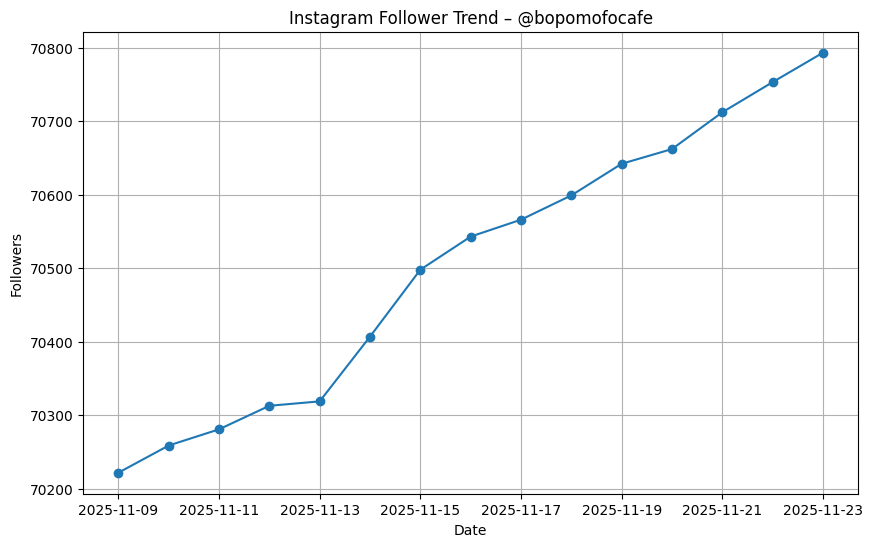

In [2]:
queries = []
if "trpcState" in data:
    queries = data["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"] and "trpcState" in data["props"]["pageProps"]:
    queries = data["props"]["pageProps"]["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"]:
    # fallback scan entire object for queries
    for v in data["props"]["pageProps"].values():
        if isinstance(v, dict) and "queries" in v:
            queries = v["queries"]

history_block = None
for q in queries:
    if q["queryKey"][0] == ["instagram", "history"]:
        history_block = q
        break

if history_block is None:
    raise Exception("Could not find the Instagram history block.")

# Extract the daily stats
days = history_block["state"]["data"]

# Build DataFrame
df = pd.DataFrame(days)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Plot
plt.figure(figsize=(10,6))
plt.plot(df["date"], df["followers"], marker="o")
plt.title("Instagram Follower Trend – @bopomofocafe")
plt.xlabel("Date")
plt.ylabel("Followers")
plt.grid(True)
plt.show()

In [3]:
print(data.keys())

dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'appGip', 'scriptLoader'])


In [6]:
props = data['props']
print(props.keys())

dict_keys(['pageProps'])


In [7]:
print("\n--- data['props'] keys ---")
print(data["props"].keys())

print("\n--- data['page'] ---")
print(data["page"])

print("\n--- data['query'] ---")
print(data["query"])



--- data['props'] keys ---
dict_keys(['pageProps'])

--- data['page'] ---
/instagram/user/[identifier]

--- data['query'] ---
{'identifier': 'bopomofocafe'}


In [8]:
print(json.dumps(data["props"]["trpcState"], indent=2)[:2000])

KeyError: 'trpcState'

In [9]:
print("props keys:", data["props"].keys())


props keys: dict_keys(['pageProps'])


In [10]:
print(json.dumps(data["props"], indent=2)[:2000])


{
  "pageProps": {
    "trpcState": {
      "json": {
        "mutations": [],
        "queries": [
          {
            "dehydratedAt": 1763919329521,
            "state": {
              "data": null,
              "dataUpdateCount": 1,
              "dataUpdatedAt": 1763919329437,
              "error": null,
              "errorUpdateCount": 0,
              "errorUpdatedAt": 0,
              "fetchFailureCount": 0,
              "fetchFailureReason": null,
              "fetchMeta": null,
              "isInvalidated": false,
              "status": "success",
              "fetchStatus": "idle"
            },
            "queryKey": [
              [
                "auth",
                "account",
                "me"
              ],
              {
                "type": "query"
              }
            ],
            "queryHash": "[[\"auth\",\"account\",\"me\"],{\"type\":\"query\"}]"
          },
          {
            "dehydratedAt": 1763919329521,
            "sta

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import time
import json
import csv

options = Options()
options.add_argument("--start-maximized")

# Make Selenium look like a normal Chrome
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option("useAutomationExtension", False)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()), 
    options=options
)

driver.execute_cdp_cmd(
    "Page.addScriptToEvaluateOnNewDocument",
    { "source": "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})" }
)


{'identifier': '2'}

In [2]:
driver.get("https://socialblade.com/instagram/user/bopomofocafe")

print("🚨 Solve the CAPTCHA manually!")
print("Press ENTER in this terminal AFTER the page fully loads")

input()  # waits for you


🚨 Solve the CAPTCHA manually!
Press ENTER in this terminal AFTER the page fully loads


''

In [ ]:
driver.execute_cdp_cmd("Network.enable", {})
events = []

timeout = time.time() + 15  # wait 15 seconds max

while time.time() < timeout:
    new_logs = driver.get_log("performance")
    events.extend(new_logs)

    for event in new_logs:
        msg = json.loads(event["message"])["message"]

        if msg["method"] == "Network.responseReceived":
            url = msg["params"]["response"]["url"]

            if "instagram.user?batch=1" in url:
                request_id = msg["params"]["requestId"]

                body = driver.execute_cdp_cmd(
                    "Network.getResponseBody",
                    {"requestId": request_id}
                )

                api_json = json.loads(body["body"])
                print("🎉 Got API JSON!")
                break

    if 'api_json' in locals():
        break

driver.quit()


In [11]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import time
import csv

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

driver.get("https://socialblade.com/instagram/user/bopomofocafe")

# wait for table to render
time.sleep(8)

# locate the daily stats table (all SocialBlade tables use this class)
rows = driver.find_elements(By.CSS_SELECTOR, ".table tbody tr")

data = []
for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")
    text = [c.text.strip() for c in cols]
    if text:
        data.append(text)

driver.quit()

# save to CSV
with open("daily_stats_from_dom.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(data)

print("Saved daily_stats_from_dom.csv")


Saved daily_stats_from_dom.csv


In [12]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import csv
import time

# --- Selenium Setup ---
options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# Step 1: Open page
driver.get("https://socialblade.com/instagram/user/bopomofocafe")

print("\n🚨 The browser is now OPEN.")
print("👉 Please:")
print("   1. Solve the Cloudflare challenge")
print("   2. Click Login if needed and sign in manually")
print("   3. Navigate BACK to the Instagram stats page")
print("💬 When the page is fully loaded, press ENTER here to continue.\n")

input("Press ENTER to continue once you're done... ")

# Step 2: Wait a bit for tables to finish rendering
time.sleep(5)

# Step 3: Scrape all daily metrics table rows
rows = driver.find_elements(By.CSS_SELECTOR, ".table tbody tr")

if not rows:
    print("❌ No table rows found. Scroll the page or check if you're on the stats page.")
    input("Scroll manually, then press ENTER...")
    rows = driver.find_elements(By.CSS_SELECTOR, ".table tbody tr")

data = []
for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")
    text = [c.text.strip() for c in cols]
    if text:
        data.append(text)

# Step 4: Save CSV
csv_file = "daily_stats_from_dom.csv"
with open(csv_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(data)

print(f"✅ Saved {len(data)} rows to {csv_file}")

print("The Selenium browser will remain open.")
print("Close the window manually when you're done.")



🚨 The browser is now OPEN.
👉 Please:
   1. Solve the Cloudflare challenge
   2. Click Login if needed and sign in manually
   3. Navigate BACK to the Instagram stats page
💬 When the page is fully loaded, press ENTER here to continue.

❌ No table rows found. Scroll the page or check if you're on the stats page.
✅ Saved 0 rows to daily_stats_from_dom.csv
The Selenium browser will remain open.
Close the window manually when you're done.
